## 0. Setup — datos del Analizador v0.3

In [10]:
# --- SETUP: VARIABLES DEL ANALIZADOR v0.3 ---

import pandas as pd
import numpy as np

# ── BLOQUE 29: dataset temporal ──────────────────────────────
datos_temporales = {
    'nombre': ['Ferretería García']*3 + ['Bar El Rincón']*3 +
              ['Peluquería Ana']*3 + ['Tienda Moda Sol']*3 +
              ['Gestoría Pérez']*3 + ['Clínica Dental Martínez']*3 +
              ['Academia Idiomas Sol']*3 + ['Clínica Dental García']*3 +
              ['Academia Idiomas English House']*3,
    'año': [2022, 2023, 2024] * 9,
    'facturacion': [
        295000, 308000, 320000,
        165000, 172000, 180000,
        85000,  90000,  95000,
        195000, 202000, 210000,
        125000, 133000, 140000,
        255000, 268000, 280000,
        145000, 152000, 160000,
        270000, 283000, 295000,
        138000, 146000, 155000,
    ],
    'margen_bruto_pct': [
        32.5, 33.1, 34.4,
        46.8, 47.0, 47.2,
        59.2, 59.5, 60.0,
        32.5, 32.9, 33.3,
        66.5, 67.2, 67.9,
        59.0, 59.5, 60.0,
        69.5, 69.7, 70.0,
        59.5, 59.8, 60.0,
        49.5, 49.7, 50.0,
    ]
}

df_temporal = pd.DataFrame(datos_temporales)
df_temporal['fecha'] = pd.to_datetime(
    df_temporal['año'].astype(str) + '-01-01')
df_temporal = df_temporal.set_index('fecha')

# ── BLOQUE 30: crecimiento interanual ────────────────────────
crecimiento = df_temporal.groupby('nombre')['facturacion'].pct_change() * 100
df_temporal['crecimiento_pct'] = crecimiento.round(1)

# ── BLOQUE 32: CAGR y calidad de crecimiento ─────────────────
resumen_temporal = []
for empresa in df_temporal['nombre'].unique():
    datos = df_temporal[
        df_temporal['nombre'] == empresa].sort_values('año')
    facturacion_inicio = datos.iloc[0]['facturacion']
    facturacion_final  = datos.iloc[-1]['facturacion']
    n_años = len(datos) - 1
    cagr = ((facturacion_final / facturacion_inicio)
            ** (1/n_años) - 1) * 100
    margen_actual = datos.iloc[-1]['margen_bruto_pct']
    resumen_temporal.append({
        'nombre':           empresa,
        'facturacion_2024': facturacion_final,
        'cagr_pct':         round(cagr, 1),
        'margen_actual':    margen_actual,
        'calidad':          round(cagr * margen_actual / 100, 2)
    })

df_crecimiento = pd.DataFrame(resumen_temporal)
df_crecimiento = df_crecimiento.sort_values('calidad', ascending=False)
df_crecimiento.index = range(1, len(df_crecimiento) + 1)

print('✅ Setup completado — variables disponibles:')
print('   df_temporal, df_crecimiento')

✅ Setup completado — variables disponibles:
   df_temporal, df_crecimiento


# Validador de Estrategias v0.1 — Mes 4

## 1. Backtest — clasificación inicial por score en 2022

In [11]:
# --- BLOQUE 1: ESTRUCTURA DEL VALIDADOR — SCORING EN 2022 ---

import pandas as pd
import numpy as np

# --- PREMISA DEL BACKTEST ---
# Pregunta: ¿las empresas con mejor score en 2022
#           crecieron más en 2023 y 2024?

# Paso 1: Calcular el score de cada empresa con datos de 2022
df_2022 = df_temporal[df_temporal['año'] == 2022].copy()
df_2022 = df_2022.set_index('nombre')

# Recalcular percentiles solo con datos de 2022
df_2022['pct_margen'] = df_2022['margen_bruto_pct'].rank(pct=True).round(2)

# En 2022 no hay crecimiento previo — usamos 0.5 como valor neutro
if 'crecimiento_pct' in df_2022.columns and df_2022['crecimiento_pct'].notna().any():
    df_2022['pct_crecimiento'] = df_2022['crecimiento_pct'].rank(
        pct=True).round(2)
else:
    df_2022['pct_crecimiento'] = 0.5

# Score 2022: 60% margen, 40% crecimiento
df_2022['score_2022'] = (
    df_2022['pct_margen'] * 0.60 +
    df_2022['pct_crecimiento'] * 0.40
).round(3)

# Clasificar en cuartiles: TOP (score >= 0.75), MID, LOW
df_2022['cuartil'] = pd.cut(
    df_2022['score_2022'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['LOW', 'MID', 'TOP']
)

print('=== CLASIFICACIÓN INICIAL — 2022 ===')
print(df_2022[['score_2022', 'cuartil',
               'margen_bruto_pct', 'facturacion']]
      .sort_values('score_2022', ascending=False))

=== CLASIFICACIÓN INICIAL — 2022 ===
                                score_2022 cuartil  margen_bruto_pct  \
nombre                                                                 
Academia Idiomas Sol                 0.800     TOP              69.5   
Gestoría Pérez                       0.734     TOP              66.5   
Clínica Dental García                0.668     TOP              59.5   
Peluquería Ana                       0.602     MID              59.2   
Clínica Dental Martínez              0.536     MID              59.0   
Academia Idiomas English House       0.464     MID              49.5   
Bar El Rincón                        0.398     MID              46.8   
Ferretería García                    0.302     LOW              32.5   
Tienda Moda Sol                      0.302     LOW              32.5   

                                facturacion  
nombre                                       
Academia Idiomas Sol                 145000  
Gestoría Pérez                  

## 2. Simulación de inversiones por cuartil

In [12]:
# --- BLOQUE 2: SIMULACIÓN DE INVERSIÓN ---

# Inversión inicial según cuartil en 2022:
# TOP: 10.000€  │  MID: 5.000€  │  LOW: 2.000€

inversion_por_cuartil = {'TOP': 10000, 'MID': 5000, 'LOW': 2000}

# Crecimiento real 2022 → 2024 por empresa
df_2024 = df_temporal[df_temporal['año'] == 2024].set_index('nombre')
df_2022_base = df_temporal[df_temporal['año'] == 2022].set_index('nombre')

resultados = []
for empresa in df_2022.index:
    cuartil = df_2022.loc[empresa, 'cuartil']
    inversion = inversion_por_cuartil[str(cuartil)]
    fact_2022 = df_2022_base.loc[empresa, 'facturacion']
    fact_2024 = df_2024.loc[empresa, 'facturacion']
    crecimiento_real = (fact_2024 - fact_2022) / fact_2022
    valor_final = round(inversion * (1 + crecimiento_real), 0)
    ganancia = round(valor_final - inversion, 0)
    resultados.append({
        'empresa':            empresa,
        'cuartil_2022':       str(cuartil),
        'score_2022':         df_2022.loc[empresa, 'score_2022'],
        'inversion':          inversion,
        'crecimiento_real_pct': round(crecimiento_real * 100, 1),
        'valor_final':        valor_final,
        'ganancia':           ganancia
    })

df_backtest = pd.DataFrame(resultados).sort_values(
    'score_2022', ascending=False)
df_backtest.index = range(1, len(df_backtest) + 1)

print('=== RESULTADOS DEL BACKTEST 2022-2024 ===')
print(df_backtest.to_string())
print(f'\nInversión total: {df_backtest["inversion"].sum():,}€')
print(f'Valor final total: {df_backtest["valor_final"].sum():,}€')
print(f'Ganancia total: {df_backtest["ganancia"].sum():,}€')

=== RESULTADOS DEL BACKTEST 2022-2024 ===
                          empresa cuartil_2022  score_2022  inversion  crecimiento_real_pct  valor_final  ganancia
1            Academia Idiomas Sol          TOP       0.800      10000                  10.3      11034.0    1034.0
2                  Gestoría Pérez          TOP       0.734      10000                  12.0      11200.0    1200.0
3           Clínica Dental García          TOP       0.668      10000                   9.3      10926.0     926.0
4                  Peluquería Ana          MID       0.602       5000                  11.8       5588.0     588.0
5         Clínica Dental Martínez          MID       0.536       5000                   9.8       5490.0     490.0
6  Academia Idiomas English House          MID       0.464       5000                  12.3       5616.0     616.0
7                   Bar El Rincón          MID       0.398       5000                   9.1       5455.0     455.0
8               Ferretería García     

## 3. Métricas del backtest

In [13]:
# --- BLOQUE 3: MÉTRICAS DE EVALUACIÓN DEL BACKTEST ---

# --- MÉTRICAS POR CUARTIL ---
metricas = df_backtest.groupby('cuartil_2022').agg(
    n_empresas=('empresa', 'count'),
    inversion_total=('inversion', 'sum'),
    valor_final_total=('valor_final', 'sum'),
    crecimiento_medio=('crecimiento_real_pct', 'mean'),
    ganancia_total=('ganancia', 'sum')
).round(1)

metricas['retorno_pct'] = (
    (metricas['valor_final_total'] - metricas['inversion_total']) /
    metricas['inversion_total'] * 100
).round(1)

print('=== MÉTRICAS POR CUARTIL DE SCORE ===')
print(metricas[['n_empresas', 'inversion_total',
                 'crecimiento_medio', 'retorno_pct']].to_string())

# --- CORRELACIÓN SCORE vs CRECIMIENTO REAL ---
# ¿Las empresas con más score crecieron más?
correlacion = df_backtest['score_2022'].corr(
    df_backtest['crecimiento_real_pct'])
print(f'\nCorrelación score 2022 vs crecimiento real: {correlacion:.2f}')
if correlacion > 0.5:
    print('✓ El modelo tiene poder predictivo positivo (correlación > 0.5)')
elif correlacion > 0.2:
    print('~ El modelo tiene poder predictivo moderado (0.2 < correlación < 0.5)')
else:
    print('✗ El modelo tiene poco poder predictivo — hay que revisar el scoring')

# --- TASA DE ACIERTO ---
# ¿Qué % de las empresas TOP crecieron más que la media?
media_crecimiento = df_backtest['crecimiento_real_pct'].mean()
top_empresas = df_backtest[df_backtest['cuartil_2022'] == 'TOP']
tasa_acierto = (
    top_empresas['crecimiento_real_pct'] > media_crecimiento
).mean() * 100
print(f'\nTasa de acierto del modelo (empresas TOP sobre la media): {tasa_acierto:.0f}%')

=== MÉTRICAS POR CUARTIL DE SCORE ===
              n_empresas  inversion_total  crecimiento_medio  retorno_pct
cuartil_2022                                                             
LOW                    2             4000                8.1          8.1
MID                    4            20000               10.8         10.7
TOP                    3            30000               10.5         10.5

Correlación score 2022 vs crecimiento real: 0.57
✓ El modelo tiene poder predictivo positivo (correlación > 0.5)

Tasa de acierto del modelo (empresas TOP sobre la media): 67%


## 4. Visualización de resultados del backtest

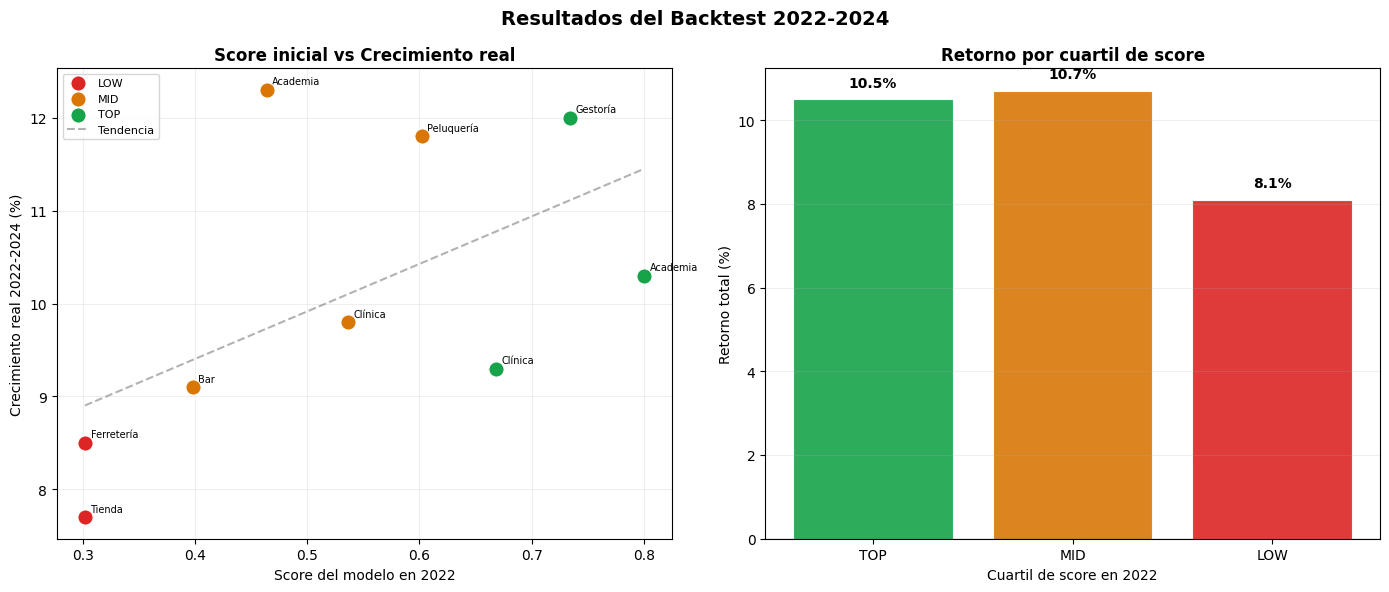

Gráfico guardado como resultados_backtest.png


In [14]:
# --- BLOQUE 4: VISUALIZACIÓN DEL BACKTEST ---

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Resultados del Backtest 2022-2024',
             fontsize=14, fontweight='bold')

# --- PANEL 1: Score 2022 vs Crecimiento real ---
colores_cuartil = {'TOP': '#16a34a', 'MID': '#d97706', 'LOW': '#dc2626'}
for cuartil, grupo in df_backtest.groupby('cuartil_2022'):
    ax1.scatter(grupo['score_2022'], grupo['crecimiento_real_pct'],
                color=colores_cuartil[cuartil], s=120, label=cuartil,
                zorder=5, edgecolors='white', linewidth=0.8)
    for _, row in grupo.iterrows():
        ax1.annotate(row['empresa'].split(' ')[0],
                     (row['score_2022'], row['crecimiento_real_pct']),
                     fontsize=7, xytext=(4, 4),
                     textcoords='offset points')

# Línea de tendencia
z = np.polyfit(df_backtest['score_2022'],
               df_backtest['crecimiento_real_pct'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_backtest['score_2022'].min(),
                     df_backtest['score_2022'].max(), 50)
ax1.plot(x_line, p_line(x_line), color='gray',
         linestyle='--', alpha=0.6, label='Tendencia')

ax1.set_xlabel('Score del modelo en 2022', fontsize=10)
ax1.set_ylabel('Crecimiento real 2022-2024 (%)', fontsize=10)
ax1.set_title('Score inicial vs Crecimiento real', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)

# --- PANEL 2: Retorno por cuartil ---
retornos = metricas['retorno_pct'].reindex(['TOP', 'MID', 'LOW'])
colores_barras = [colores_cuartil[c] for c in retornos.index]
bars = ax2.bar(retornos.index, retornos.values,
               color=colores_barras, edgecolor='white',
               linewidth=0.8, alpha=0.9)
for bar, val in zip(bars, retornos.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=10, fontweight='bold')

ax2.set_xlabel('Cuartil de score en 2022', fontsize=10)
ax2.set_ylabel('Retorno total (%)', fontsize=10)
ax2.set_title('Retorno por cuartil de score', fontweight='bold')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('resultados_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como resultados_backtest.png')

## 5. Exportación — Excel con informe del backtest

In [15]:
# --- BLOQUE 5: EXPORTACIÓN DEL INFORME DEL BACKTEST ---

!pip install openpyxl -q
nombre_archivo = 'backtest_v01.xlsx'

with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:

    # Hoja 1: Resultados empresa a empresa
    df_backtest.to_excel(
        writer, sheet_name='Resultados empresa', index=True)

    # Hoja 2: Métricas por cuartil
    metricas.to_excel(
        writer, sheet_name='Métricas por cuartil')

    # Hoja 3: Resumen ejecutivo
    resumen = pd.DataFrame({
        'Métrica': [
            'Inversión total simulada',
            'Valor final total',
            'Ganancia total',
            'Retorno total (%)',
            'Correlación score-crecimiento',
            'Tasa de acierto empresas TOP',
            'Período del backtest'
        ],
        'Valor': [
            f'{df_backtest["inversion"].sum():,}€',
            f'{df_backtest["valor_final"].sum():,}€',
            f'{df_backtest["ganancia"].sum():,}€',
            f'{(df_backtest["valor_final"].sum() / df_backtest["inversion"].sum() - 1)*100:.1f}%',
            f'{correlacion:.2f}',
            f'{tasa_acierto:.0f}%',
            '2022 → 2024 (2 años)'
        ]
    })
    resumen.to_excel(
        writer, sheet_name='Resumen ejecutivo', index=False)

print(f'Excel guardado: {nombre_archivo}')
print('Hojas: Resultados empresa, Métricas por cuartil, Resumen ejecutivo')

Excel guardado: backtest_v01.xlsx
Hojas: Resultados empresa, Métricas por cuartil, Resumen ejecutivo
